In [1]:
import sys
sys.path.append('..')

In [2]:
## importing, please use env: hoiqel
import numpy as np
from matplotlib import pyplot as plt
from QuantumCompiler.WaveModule import Wave
from qel.drivers.Tektronix.Tektronix_AWG import AWG5208

In [4]:
## connect to AWG
awg = AWG5208(inst_name='AWG5208', inst_address='TCPIP0::192.168.10.171::inst0::INSTR')

Connect Instrument:
instrument: AWG5208
statement: TEKTRONIX,AWG5208,B030598,FV:6.6.0131.0


In [11]:
## set config
SAMPLING_RATE = 1e9  # 1 GHz

awg.set_sample_rate(sample_rate=SAMPLING_RATE)
awg.set_extref_source(ref_freq=10e6)
awg.set_ch_mkr(ch_mkr3=1) # set `n`-bit for marker use for channel 'm'
awg.set_ch_amp(
    ch=1,
    wfm_Vpp=100e-3, # peak-to-peak voltage of waveform, waveform -400mV ~ +400mV for our ADC
    wfm_offset=0, # offset voltage of waveform, waveform -400mV ~ +400mV for our ADC
    mkr1=1 # marker voltage, trigger max is 5 volt for our ADC
)

In [6]:
awg.stop()

In [12]:
awg.play()

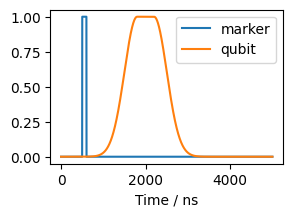

In [7]:
## make waveforms
x_span=5000e-9
sampling_rate=SAMPLING_RATE

# examples:
# Wave(('gaussian_square', {'first_peak_x': 1600e-9, 'flat': 800e-9, 'sigma': 100e-9}, x_span, sampling_rate, 'ex1'))
# Wave(('square', {'start': 1000e-9, 'flat': 800e-9}, x_span, sampling_rate, 'ex2'))
# Wave(('const', {'lv': 1.0}, x_span, sampling_rate, 'ex3'))

# readout_wv = Wave(('gaussian_square', {'first_peak_x': 1600e-9, 'flat': 800e-9, 'sigma': 100e-9}, x_span, sampling_rate, 'readout'))
# readout_wv = Wave(('square', {'start': 1000e-9, 'flat': 800e-9}, x_span, sampling_rate, 'readout'))

qubit_wv = Wave(('gaussian_square', {'first_peak_x': 1800e-9, 'flat': 400e-9, 'sigma': 300e-9}, x_span, sampling_rate, 'qubit'))
# qubit_wv = Wave(('const', {'lv': 0.0}, x_span, sampling_rate, 'qubit'))
# qubit_wv = Wave(('square', {'start': 500e-9, 'flat': 100e-9}, x_span, sampling_rate, 'qubit'))


marker_wv = Wave(('square', {'start': 500e-9, 'flat': 100e-9}, x_span, sampling_rate, 'marker'))
reset_wv = Wave(('const', {'lv': 1.0}, x_span, sampling_rate, 'reset'))


## plot
plt.figure(figsize=(3, 2))
plt.plot(1e9*marker_wv.x, marker_wv.y, label='marker')
# plt.plot(1e9*readout_wv.x, readout_wv.y, label='readout')
plt.plot(1e9*qubit_wv.x, qubit_wv.y, label='qubit')
plt.xlabel('Time / ns')
plt.legend()
plt.show()

In [8]:
# clear and set new waveforms to AWG
def clear_and_setwf():
    """Clean up waveform and sequence list in AWG, then upload new waveforms."""
    # stop and clear sequence list and waveform list in AWG.
    awg.clean_up()

    # upload new waveforms
    awg.set_wfm(wfm_name='qubit', wfm=qubit_wv.y[:-1], mkr1=marker_wv.y[:-1])
    # awg.set_wfm(wfm_name='readout', wfm=readout_wv.y[:-1], mkr1=marker_wv.y[:-1])
    # awg.set_wfm(wfm_name='reset', wfm=reset_wv.y[:-1], mkr1=marker_wv.y[:-1])
    awg.upload_wfm()

    # assign waveforms to channels
    awg.assign_ch(1, 'qubit')
    # awg.assign_ch(7, 'readout')

clear_and_setwf()

In [24]:
awg.stop()

In [7]:
awg.play()